# Hybrid Prior-Drift + Scheduled Noise

Explores decaying noise schedules $\sigma(\text{age}) = C + \Delta \cdot f(\text{age}, \lambda)$ combined with prior-guided drift in the 2D GMM sandbox.

**Key question:** Which schedule best reproduces the steep-initial-drop then stable-asymptote d' curve seen in human data?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

from src.model.analytic_gmm_2d import AnalyticGMM2D
from src.model.score_adapter_2d import ScoreAdapter2D
from utls.sandbox_2d_data import make_2d_grid_stimuli
from utls.toy_experiments import make_high_diversity_sequences
from utls.runners_2d import run_model_core_2d_vec
from utls.roc_utils import roc_for_isi, auroc_to_dprime
from utls.noise_schedules import (
    ConstantSchedule, ExponentialDecay, PowerLawDecay,
    InverseLinearDecay, LinearDecay, make_decay_schedule,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('imports OK')

imports OK


## Section 1 — Setup

In [6]:
# GMM prior (default 3-component)
gmm = AnalyticGMM2D()
score_model = ScoreAdapter2D(gmm, normalize=True)

# Stimuli
X0, name_to_idx, stimulus_pool = make_2d_grid_stimuli(n_side=9)
print(f"Stimuli: {X0.shape[0]} points in R^{X0.shape[1]}")

# Experiment sequences
ISI_VALUES = [0, 1, 2, 4, 8, 16, 32, 64]
experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool, ISI_VALUES,
    n_sequences=400, length=120, seed=42, min_pairs_per_isi=4,
)
print(f"Sequences: {len(experiment_list)}, length ~{len(experiment_list[0])}")

Aggregate ISI usage across all sequences:
  ISI -1: 16000
  ISI 0: 4276
  ISI 1: 3702
  ISI 2: 4000
  ISI 4: 4026
  ISI 8: 4078
  ISI 16: 3948
  ISI 32: 4016
  ISI 64: 3954
Sequences: 400, length ~120


In [7]:
def compute_dprime_by_isi(run_data, isi_values):
    """Extract d'(ISI) curve from a single model run."""
    dprimes = {}
    for isi in isi_values:
        # Runner stores isi = t - last_seen (1-indexed), so experiment
        # ISI=k maps to runner key k+1.  Same convention as run_2d_isi_sweep.
        runner_isi = isi + 1
        result = roc_for_isi(run_data, runner_isi)
        if result is not None:
            _, _, auroc = result
            dprimes[isi] = auroc_to_dprime(auroc)
        else:
            dprimes[isi] = np.nan
    return dprimes


def run_and_get_dprime(sigma0, sigma, drift_step_size, experiment_list, name_to_idx, noise_schedule=None,
                       n_reps=5, seed_base=0):
    """Run model n_reps times, return mean d'(ISI) curve."""
    all_dprimes = defaultdict(list)
    for rep in range(n_reps):
        out = run_model_core_2d_vec(
            sigma0=sigma0, sigma=sigma,
            X0=X0, name_to_idx=name_to_idx,
            experiment_list=experiment_list,
            score_model=score_model,
            drift_step_size=drift_step_size,
            noise_schedule=noise_schedule,
            metric="cosine",
            seed=seed_base + rep,
        )
        dp = compute_dprime_by_isi(out, ISI_VALUES)
        for isi, val in dp.items():
            all_dprimes[isi].append(val)
    return {isi: np.nanmean(vals) for isi, vals in all_dprimes.items()}

## Section 2 — Visualise the Schedules

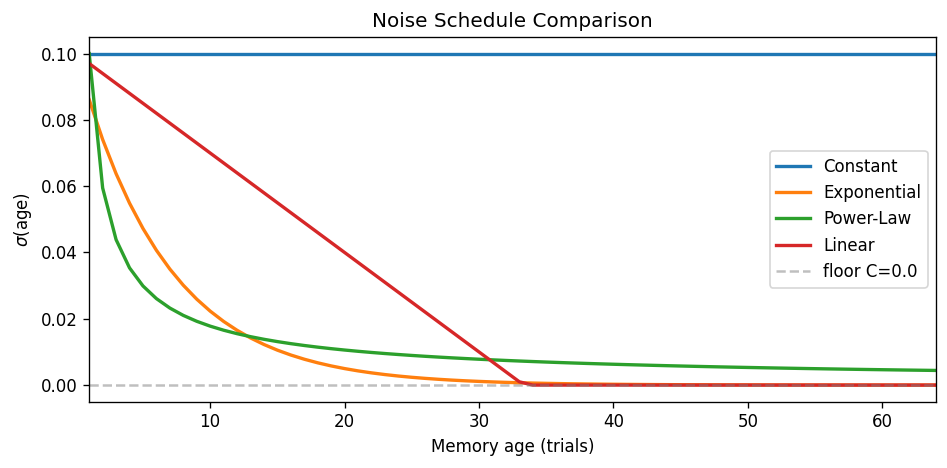

In [9]:
# Common parameters: floor C=0.02, Delta=0.08 (so sigma_max=0.10), rate=0.15
C, DELTA, RATE = 0.00, 0.1, 0.15

schedules = {
    "Constant":       ConstantSchedule(floor=C + DELTA),
    "Exponential":    ExponentialDecay(floor=C, delta=DELTA, rate=RATE),
    "Power-Law":      PowerLawDecay(floor=C, delta=DELTA, rate=RATE * 5),  # needs larger rate
    "Linear":         LinearDecay(floor=C, delta=DELTA, rate=RATE / 50),
}

ages = torch.arange(1, 65)

fig, ax = plt.subplots(figsize=(8, 4))
for name, sched in schedules.items():
    sigma_vals = sched(ages).numpy() if isinstance(sched(ages), torch.Tensor) else np.array([sched(a) for a in range(1, 65)])
    ax.plot(range(1, 65), sigma_vals, label=name, linewidth=2)

ax.axhline(C, color='gray', linestyle='--', alpha=0.5, label=f'floor C={C}')
ax.set_xlabel('Memory age (trials)')
ax.set_ylabel(r'$\sigma(\mathrm{age})$')
ax.set_title('Noise Schedule Comparison')
ax.legend()
ax.set_xlim(1, 64)
plt.tight_layout()
plt.show()

## Section 3 — Single-Parameter-Set Comparison

Fix $\eta$ at a reasonable value. Run each schedule + prior drift at multiple ISIs. Compare d'(ISI) curves.

In [14]:
ETA = 0.05   # drift step size
SIGMA0 = 0.01  # no encoding noise (absorbed into schedule)
DELTA = 0.2
N_REPS = 1

# Baseline: constant sigma M2
dp_constant = run_and_get_dprime(SIGMA0, DELTA, ETA, experiment_list, name_to_idx, noise_schedule=None, n_reps=N_REPS)
print("Constant (M2 baseline):", {k: f"{v:.2f}" for k, v in dp_constant.items()})

# Each schedule
dp_results = {"Constant (M2)": dp_constant}
for name, sched in schedules.items():
    if name == "Constant":
        continue
    dp = run_and_get_dprime(SIGMA0, DELTA, ETA, experiment_list, name_to_idx, noise_schedule=sched, n_reps=N_REPS)
    dp_results[name] = dp
    print(f"{name}: {({k: f'{v:.2f}' for k, v in dp.items()})}")

Constant (M2 baseline): {0: '0.69', 1: '0.50', 2: '0.48', 4: '0.32', 8: '0.35', 16: '0.31', 32: '0.34', 64: '0.37'}
Exponential: {0: '1.10', 1: '0.97', 2: '0.89', 4: '0.71', 8: '0.55', 16: '0.31', 32: '0.24', 64: '0.22'}
Power-Law: {0: '1.06', 1: '0.95', 2: '0.89', 4: '0.72', 8: '0.55', 16: '0.31', 32: '0.24', 64: '0.21'}
Linear: {0: '1.06', 1: '0.90', 2: '0.83', 4: '0.66', 8: '0.54', 16: '0.33', 32: '0.26', 64: '0.21'}


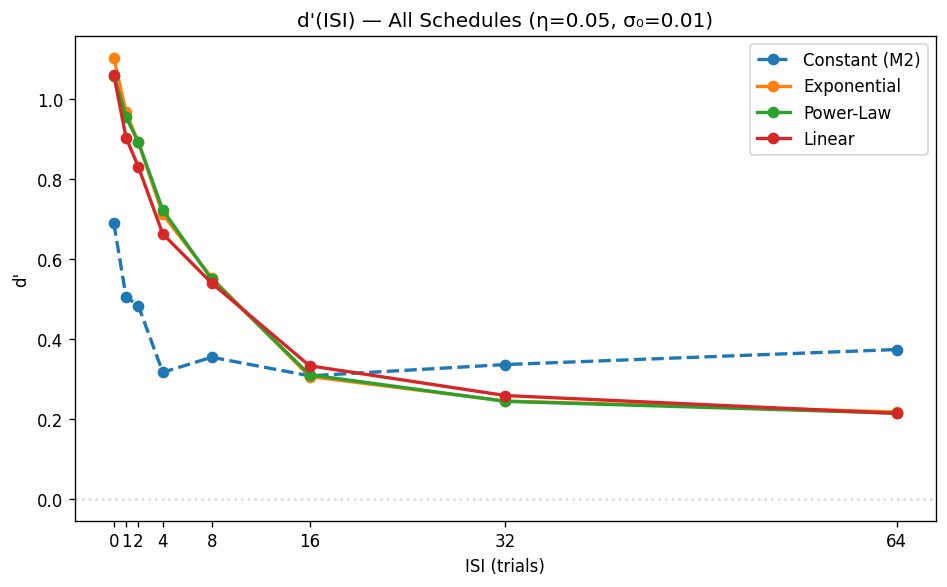

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, dp in dp_results.items():
    isis = sorted(dp.keys())
    vals = [dp[i] for i in isis]
    style = '--' if 'M2' in name else '-'
    ax.plot(isis, vals, style, marker='o', label=name, linewidth=2)

ax.set_xlabel('ISI (trials)')
ax.set_ylabel("d'")
ax.set_title(f'd\'(ISI) — All Schedules (η={ETA}, σ₀={SIGMA0})')
ax.legend()
ax.set_xticks(ISI_VALUES)
ax.set_xticklabels(ISI_VALUES)
ax.axhline(0, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4 — η × Schedule Interaction

For the top schedule(s), sweep η to see whether the schedule controls *shape* while η controls *floor*.

In [ ]:
eta_values = [0.0, 0.02, 0.05, 0.1, 0.2]
schedule = ExponentialDecay(floor=C, delta=DELTA, rate=RATE)

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(eta_values)))

for i, eta in enumerate(eta_values):
    dp = run_and_get_dprime(SIGMA0, C + DELTA, eta, noise_schedule=schedule, n_reps=N_REPS)
    isis = sorted(dp.keys())
    ax.plot(isis, [dp[k] for k in isis], '-o', color=cmap[i],
            label=f'η={eta}', linewidth=2)

ax.set_xlabel('ISI (trials)')
ax.set_ylabel("d'")
ax.set_title('Exponential Decay — η sweep')
ax.legend()
ax.set_xscale('log', base=2)
ax.set_xticks(ISI_VALUES)
ax.set_xticklabels(ISI_VALUES)
plt.tight_layout()
plt.show()

## Section 5 — Parameter Sensitivity

2D heatmaps: d'(ISI=16) and d'(ISI=4) as functions of (Δ, λ) at fixed C and η.

In [ ]:
delta_vals = np.linspace(0.02, 0.15, 6)
rate_vals = np.linspace(0.05, 0.4, 6)

dp_map_isi4 = np.zeros((len(delta_vals), len(rate_vals)))
dp_map_isi16 = np.zeros_like(dp_map_isi4)

for i, d in enumerate(delta_vals):
    for j, r in enumerate(rate_vals):
        sched = ExponentialDecay(floor=C, delta=d, rate=r)
        dp = run_and_get_dprime(SIGMA0, C + d, ETA, noise_schedule=sched, n_reps=5)
        dp_map_isi4[i, j] = dp.get(4, np.nan)
        dp_map_isi16[i, j] = dp.get(16, np.nan)
    print(f"  delta={d:.3f} done")

print("Grid search complete.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(axes, [dp_map_isi4, dp_map_isi16],
                           ["d'(ISI=4)", "d'(ISI=16)"]):
    im = ax.imshow(data, origin='lower', aspect='auto',
                   extent=[rate_vals[0], rate_vals[-1],
                           delta_vals[0], delta_vals[-1]])
    ax.set_xlabel('rate (λ)')
    ax.set_ylabel('Δ (excess noise)')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.suptitle(f'Exponential Decay — C={C}, η={ETA}', fontsize=12)
plt.tight_layout()
plt.show()

## Section 6 — Floor Analysis

Compare C=0 vs C>0 for the exponential schedule. Show coalescence with no floor.

In [ ]:
floor_values = [0.0, 0.01, 0.02, 0.04]

fig, ax = plt.subplots(figsize=(8, 5))
for c_val in floor_values:
    sched = ExponentialDecay(floor=c_val, delta=DELTA, rate=RATE)
    dp = run_and_get_dprime(SIGMA0, c_val + DELTA, ETA, noise_schedule=sched, n_reps=N_REPS)
    isis = sorted(dp.keys())
    ax.plot(isis, [dp[k] for k in isis], '-o', label=f'C={c_val}', linewidth=2)

ax.set_xlabel('ISI (trials)')
ax.set_ylabel("d'")
ax.set_title(f'Floor Analysis — Exponential Decay (Δ={DELTA}, λ={RATE}, η={ETA})')
ax.legend()
ax.set_xscale('log', base=2)
ax.set_xticks(ISI_VALUES)
ax.set_xticklabels(ISI_VALUES)
ax.axhline(0, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7 — Backward Compatibility Check

Verify that `noise_schedule=None` and `ConstantSchedule(sigma)` produce identical results.

In [ ]:
SIGMA_TEST = 0.05
SEED_TEST = 12345

# Run with noise_schedule=None (original behaviour)
out_baseline = run_model_core_2d_vec(
    sigma0=0.1, sigma=SIGMA_TEST,
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list,
    score_model=score_model,
    drift_step_size=0.05,
    noise_schedule=None,
    metric="cosine", seed=SEED_TEST,
)

# Run with ConstantSchedule(sigma) — should match
out_const = run_model_core_2d_vec(
    sigma0=0.1, sigma=SIGMA_TEST,
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list,
    score_model=score_model,
    drift_step_size=0.05,
    noise_schedule=ConstantSchedule(floor=SIGMA_TEST),
    metric="cosine", seed=SEED_TEST,
)

# Compare
hits_match = np.allclose(out_baseline['hits'], out_const['hits'], atol=1e-6)
fas_match = np.allclose(out_baseline['fas'], out_const['fas'], atol=1e-6)
print(f"Hits match: {hits_match}")
print(f"FAs match:  {fas_match}")
if hits_match and fas_match:
    print("Backward compatibility PASSED")
else:
    print("WARNING: outputs differ!")
    print(f"  Max hit diff: {np.max(np.abs(out_baseline['hits'] - out_const['hits'])):.2e}")
    print(f"  Max FA diff:  {np.max(np.abs(out_baseline['fas'] - out_const['fas'])):.2e}")